## Abdurrahmansoftw@gmail.com

ML Assignment -1

Dataset: Titanic Dataset (titanic_data_updated.csv)

Total Marks: 100

Email:

Name:

Exam Instructions :
- প্রথমে একটি Google Colab ফাইল খুলবে , এরপর প্রথম cell এ নিজের নাম এবং কোর্সে registration করা ইমেইল দিবে
- Question wise numbering করে Text cell রাখবে এবং এর নিচে Code cell থাকবে, চেষ্টা করবে একটি code cell এ একটি question উত্তর দেয়ার
- Google colab এর মধ্যে কোডগুলো করবে
- এবং সেই ফাইলটি ‘Anyone with the link’ & ‘View’ Access দিয়ে ফাইলটির Shareble Link টি সাবমিট করবে।


# Question 1 (10 Marks)
Load the Titanic dataset and display:
- Dataset shape
- First 10 rows
- 5 random samples

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')


In [ ]:
df = pd.read_csv('titanic_data_updated.csv')

print(df.shape)

print(df.head(10))

print(df.sample(5))

(891, 12)
   PassengerId Survived  Pclass  \
0            1       no   third   
1            2      yes   first   
2            3      yes   third   
3            4      yes   first   
4            5       no   third   
5            6       no   third   
6            7       no   first   
7            8       no   third   
8            9      yes   third   
9           10      yes  second   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarthy, Mr. Timothy J    male  54.

# Question 2 (10 Marks)
Perform feature screening on the Titanic dataset by:
- Finding total missing values
- Finding duplicate rows
- Removing duplicate rows permanently

In [ ]:
print(df.isnull().sum())
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)
print(df.shape)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
0
(891, 12)


# Question 3 (10 Marks)
Perform statistical profiling of the Titanic dataset and display:
- Dataset information
- Statistical summary of numerical columns

Also write 2 observations from the output.


In [ ]:
df.info()
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB
       PassengerId         Age       SibSp       Parch        Fare
count   891.000000  714.000000  891.000000  891.000000  891.000000
mean    446.000000   29.699118    0.523008    0.381594   32.204208
std     257.353842   14.526497    1.102743 

# Question 4 (10 Marks)
Perform univariate categorical analysis on the Survived column by:
- Creating a countplot
- Calculating percentage distribution
- Creating a pie chart

Write 2 insights from the analysis.

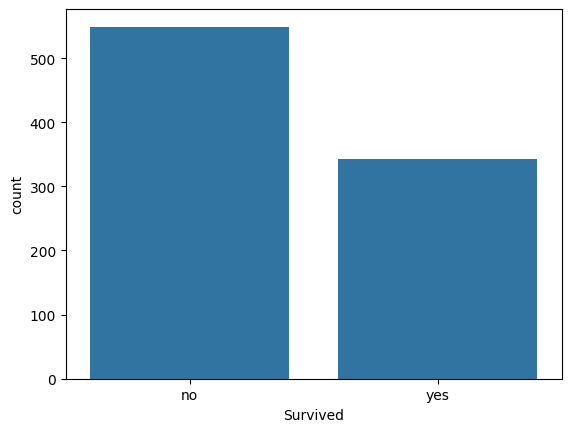



Survived
no     61.616162
yes    38.383838
Name: proportion, dtype: float64


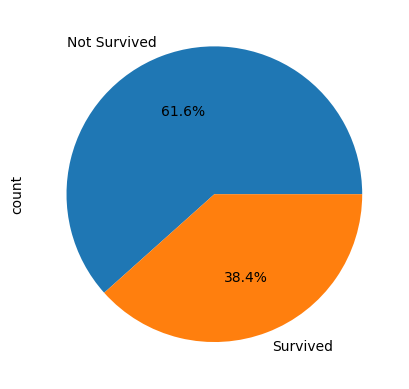

In [ ]:
sns.countplot(x='Survived', data=df)
plt.show()


print('\n')


print(df['Survived'].value_counts(normalize=True) * 100)

df['Survived'].value_counts().plot(
    kind='pie', labels=['Not Survived', 'Survived'], autopct='%1.1f%%')
plt.show()

# Question 5 (10 Marks)
Perform univariate numerical analysis on the Age column by:
- Creating a histogram
- Creating a KDE plot

Write 2 observations from the plots.


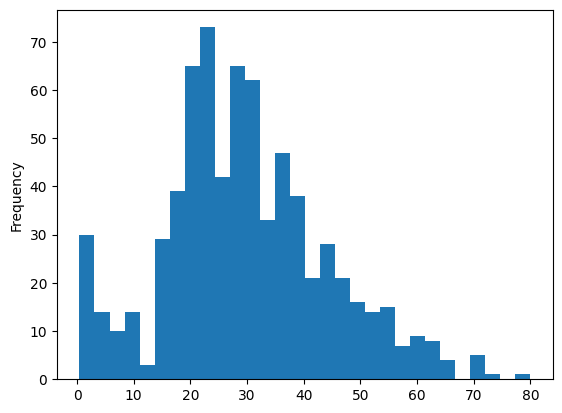

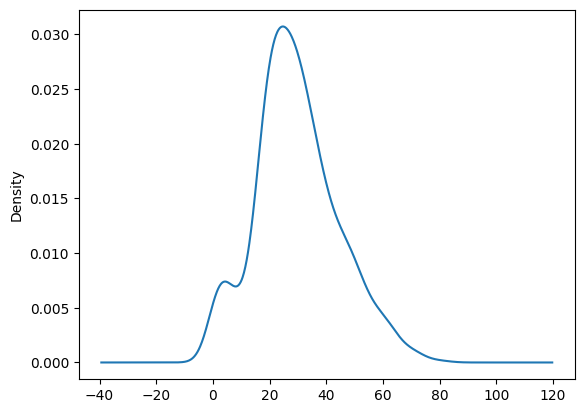

In [ ]:
df['Age'].plot(kind='hist', bins=30)
plt.show()

df['Age'].plot(kind='kde')
plt.show()

# Question 6 (10 Marks)
Perform multivariate analysis between Sex and Survived using a countplot with hue.

Also calculate normalized survival ratios using groupby().

Write 2 insights from the analysis.


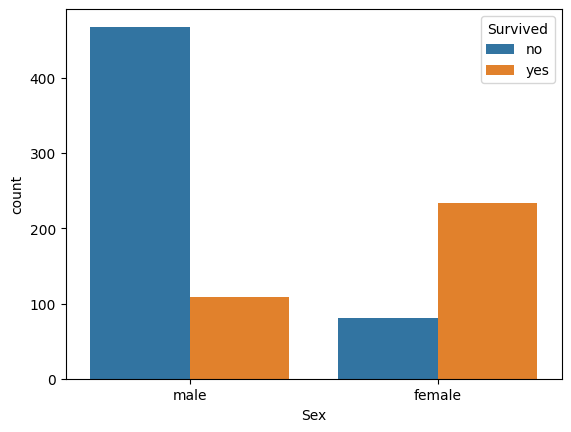

In [ ]:
df['Survived'] = df['Survived'].astype(str)

sns.countplot(x='Sex', hue='Survived', data=df)

plt.show()

# Question 7 (10 Marks)

Create a barplot showing the relationship between Pclass and Fare.

Write 2 observations from the visualization.


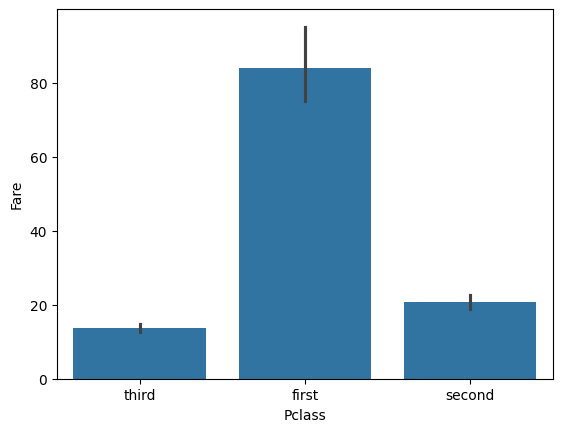

In [ ]:
sns.barplot(x='Pclass', y='Fare', data=df)
plt.show()

# Question 8 (10 Marks)

Create a KDE plot to compare the Age distribution of survived and non-survived passengers.

Write 2 insights from the graph.


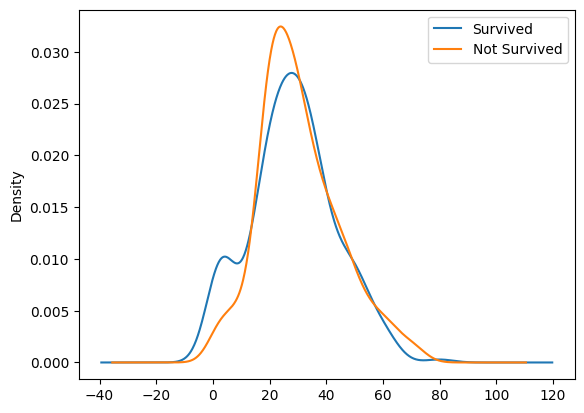

In [ ]:

df[df['Survived'] == 'yes']['Age'].plot(kind='kde', label='Survived')

df[df['Survived'] == 'no']['Age'].plot(kind='kde', label='Not Survived')

plt.legend()

plt.show()

# Question 9 (10 Marks)
Perform feature engineering and train-test split by:
- Dropping PassengerId, Name, and Ticket columns
- Separating features (X) and target (y)
- Splitting the dataset using test_size=0.2 and random_state=42

Display the shapes of train and test datasets.


In [ ]:
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(712, 8)
(179, 8)
(712,)
(179,)


# Question 10 (10 Marks)
Handle missing values in the Titanic dataset by:
- Imputing missing Age values using SimpleImputer with mean strategy
- Imputing missing Embarked values using most frequent strategy
- Imputing missing Cabin values using constant strategy with "Missing"

Finally, check whether any missing values remain.


In [ ]:
age_imputer = SimpleImputer(strategy='mean')
df['Age'] = age_imputer.fit_transform(df[['Age']])

embarked_imputer = SimpleImputer(strategy='most_frequent')
df['Embarked'] = embarked_imputer.fit_transform(df[['Embarked']]).ravel()

cabin_imputer = SimpleImputer(strategy='constant', fill_value='Missing')
df['Cabin'] = cabin_imputer.fit_transform(df[['Cabin']]).ravel()

print(df.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Cabin       0
Embarked    0
dtype: int64
